In [1]:
import sys

In [2]:
#!{sys.executable} -m pip install xgboost

In [3]:
sys.executable

'c:\\ProgramData\\anaconda3\\python.exe'

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
#from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

import math

from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score

In [5]:
#path of csv data
file_path = 'TelecomChurn_POC.csv'

In [6]:
# reading dataframe
df = pd.read_csv(file_path)
df.head()

,customer_id,age,gender,region,senior_citizen,partner,tenure_months,contract_type,payment_method,internet_service,monthly_charges,total_charges,avg_monthly_calls,data_usage_gb,support_tickets,streaming_tv,tech_support,online_backup,churn
0,CUST665822,56,Male,East,0,0,40,One Year,Bank Transfer,NaN,48.63,1969.30,54,7.05,0,1,0,1,0
1,CUST327221,69,Female,North,1,0,47,Month-to-Month,Electronic Check,DSL,20.00,NaN,45,37.20,1,0,1,0,0
2,CUST805684,46,Other,North,0,1,15,Month-to-Month,Credit Card,Fiber Optic,94.69,1389.05,45,5.78,4,0,1,0,1
3,CUST085472,32,Female,East,0,1,15,Two Year,Electronic Check,Fiber Optic,65.36,956.60,40,3.34,1,1,0,0,0
4,CUST568785,60,Female,East,1,1,72,One Year,Electronic Check,NaN,63.82,4617.34,33,13.56,2,1,0,0,0


In [7]:
#Statistic Summary of dataframe
df.describe()

,age,senior_citizen,partner,tenure_months,monthly_charges,total_charges,avg_monthly_calls,data_usage_gb,support_tickets,streaming_tv,tech_support,online_backup,churn
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,4800.000000,5000.000000,4900.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,46.672800,0.27540,0.544800,26.489000,67.209722,1791.945775,45.109200,12.342698,1.488200,0.553200,0.451200,0.498000,0.181400
std,16.630005,0.44676,0.498039,22.319837,35.975521,1908.603957,6.704019,12.350321,1.210353,0.497211,0.497663,0.500046,0.385388
min,18.000000,0.00000,0.000000,1.000000,20.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,0.00000,0.000000,8.000000,47.887500,453.295000,41.000000,3.500000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,47.000000,0.00000,1.000000,20.000000,64.605000,1177.680000,45.000000,8.175000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.00000,1.000000,40.000000,82.460000,2560.865000,49.000000,17.330000,2.000000,1.000000,1.000000,1.000000,0.000000
max,75.000000,1.00000,1.000000,72.000000,496.100000,26845.400000,67.000000,94.640000,7.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
#checking info about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   age                5000 non-null   int64  
 2   gender             5000 non-null   object 
 3   region             5000 non-null   object 
 4   senior_citizen     5000 non-null   int64  
 5   partner            5000 non-null   int64  
 6   tenure_months      5000 non-null   int64  
 7   contract_type      5000 non-null   object 
 8   payment_method     5000 non-null   object 
 9   internet_service   4261 non-null   object 
 10  monthly_charges    5000 non-null   float64
 11  total_charges      4800 non-null   float64
 12  avg_monthly_calls  5000 non-null   int64  
 13  data_usage_gb      4900 non-null   float64
 14  support_tickets    5000 non-null   int64  
 15  streaming_tv       5000 non-null   int64  
 16  tech_support       5000 

In [9]:
#removing duplicate records and checking shape of dataframe
df = df.drop_duplicates()
df.shape

(5000, 19)

In [10]:
# checking empty values
df.isna().sum()

customer_id            0
age                    0
gender                 0
region                 0
senior_citizen         0
partner                0
tenure_months          0
contract_type          0
payment_method         0
internet_service     739
monthly_charges        0
total_charges        200
avg_monthly_calls      0
data_usage_gb        100
support_tickets        0
streaming_tv           0
tech_support           0
online_backup          0
churn                  0
dtype: int64

In [11]:
# Calculate percentage of missing values per column
null_perc = (df.isnull().sum() / len(df)) * 100
print(null_perc)

customer_id           0.00
age                   0.00
gender                0.00
region                0.00
senior_citizen        0.00
partner               0.00
tenure_months         0.00
contract_type         0.00
payment_method        0.00
internet_service     14.78
monthly_charges       0.00
total_charges         4.00
avg_monthly_calls     0.00
data_usage_gb         2.00
support_tickets       0.00
streaming_tv          0.00
tech_support          0.00
online_backup         0.00
churn                 0.00
dtype: float64


In [12]:
# internet service None Category is treated as Null, so converting it to None
df['internet_service'] = df['internet_service'].fillna('None')
df.isna().sum()

customer_id            0
age                    0
gender                 0
region                 0
senior_citizen         0
partner                0
tenure_months          0
contract_type          0
payment_method         0
internet_service       0
monthly_charges        0
total_charges        200
avg_monthly_calls      0
data_usage_gb        100
support_tickets        0
streaming_tv           0
tech_support           0
online_backup          0
churn                  0
dtype: int64

C:\Users\shubh\AppData\Local\Temp\ipykernel_25804\1735926834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['total_charges'],ax=ax1,palette="Set1")
C:\Users\shubh\AppData\Local\Temp\ipykernel_25804\1735926834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['data_usage_gb'],ax=ax2,palette='Set2')


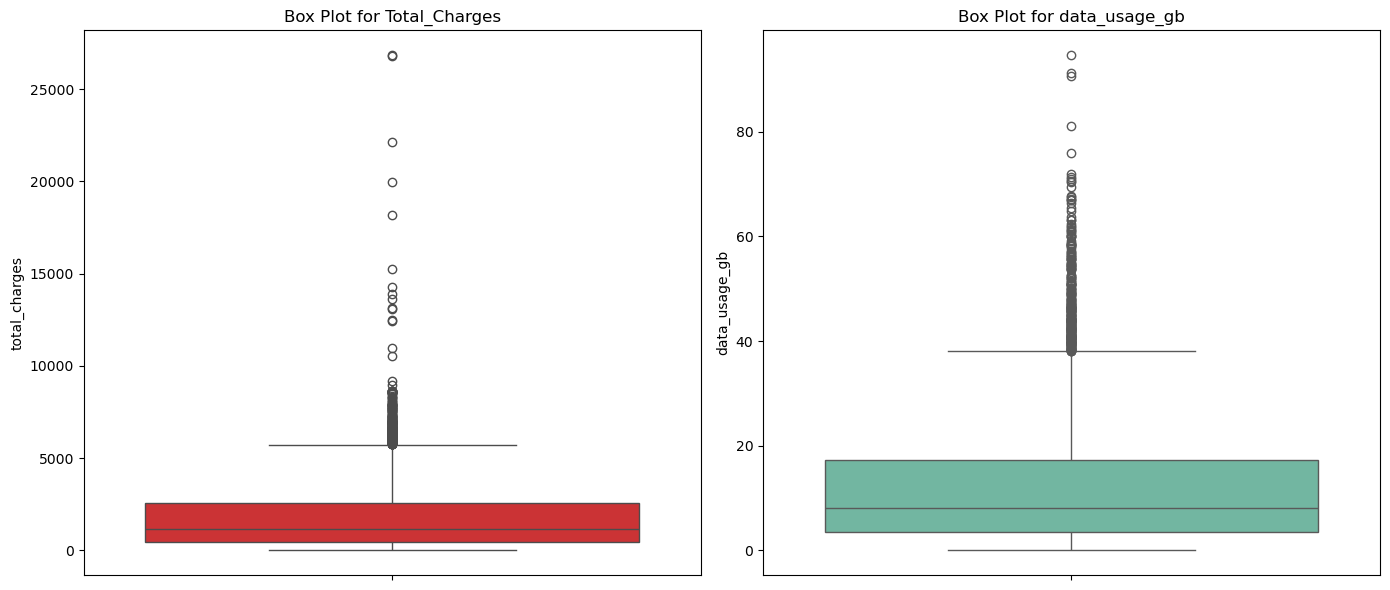

In [13]:
#checking for outliers
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
sns.boxplot(df['total_charges'],ax=ax1,palette="Set1")
ax1.set_title("Box Plot for Total_Charges")
sns.boxplot(df['data_usage_gb'],ax=ax2,palette='Set2')
ax2.set_title("Box Plot for data_usage_gb")

plt.tight_layout()
plt.show()

As there are many outliers we will filling the empty values with median values instead of average, as average is sensitive to outliers.

In [14]:
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())
df['data_usage_gb'] = df['data_usage_gb'].fillna(df['data_usage_gb'].median())

In [15]:
df.isna().sum()

customer_id          0
age                  0
gender               0
region               0
senior_citizen       0
partner              0
tenure_months        0
contract_type        0
payment_method       0
internet_service     0
monthly_charges      0
total_charges        0
avg_monthly_calls    0
data_usage_gb        0
support_tickets      0
streaming_tv         0
tech_support         0
online_backup        0
churn                0
dtype: int64

In [16]:
# converting object datatype to category
obj_col = ['gender','region','contract_type','payment_method','internet_service']
df[obj_col] = df[obj_col].astype('category')
df.dtypes

   


customer_id            object
age                     int64
gender               category
region               category
senior_citizen          int64
partner                 int64
tenure_months           int64
contract_type        category
payment_method       category
internet_service     category
monthly_charges       float64
total_charges         float64
avg_monthly_calls       int64
data_usage_gb         float64
support_tickets         int64
streaming_tv            int64
tech_support            int64
online_backup           int64
churn                   int64
dtype: object

### EDA

In [17]:
# storing list of numerical column in num_cols variable
num_cols = df.select_dtypes('number').columns.tolist()
num_cols

['age',
 'senior_citizen',
 'partner',
 'tenure_months',
 'monthly_charges',
 'total_charges',
 'avg_monthly_calls',
 'data_usage_gb',
 'support_tickets',
 'streaming_tv',
 'tech_support',
 'online_backup',
 'churn']

In [18]:
# storing list of numerical column in num_cols variable
cat_cols = df.select_dtypes('category').columns.tolist()
cat_cols

['gender', 'region', 'contract_type', 'payment_method', 'internet_service']

**Univariant Analysis**

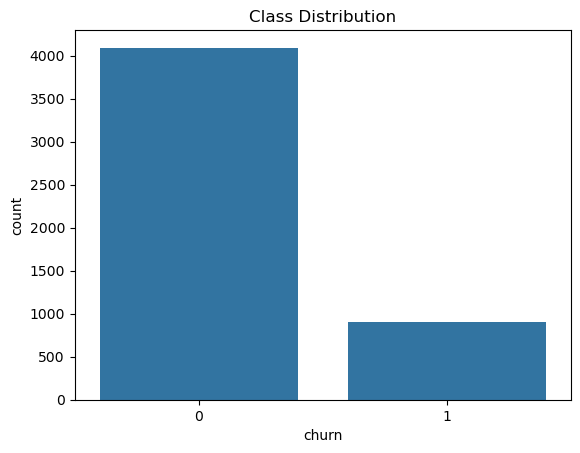

churn
0    0.8186
1    0.1814
Name: proportion, dtype: float64


In [19]:
sns.countplot(x='churn', data=df)
plt.title("Class Distribution")
plt.show()

print(df['churn'].value_counts(normalize=True))

From the Distribution we can observe there is class imbalance for churn variable. 19% of customers are churn where as 81% people are not churn.

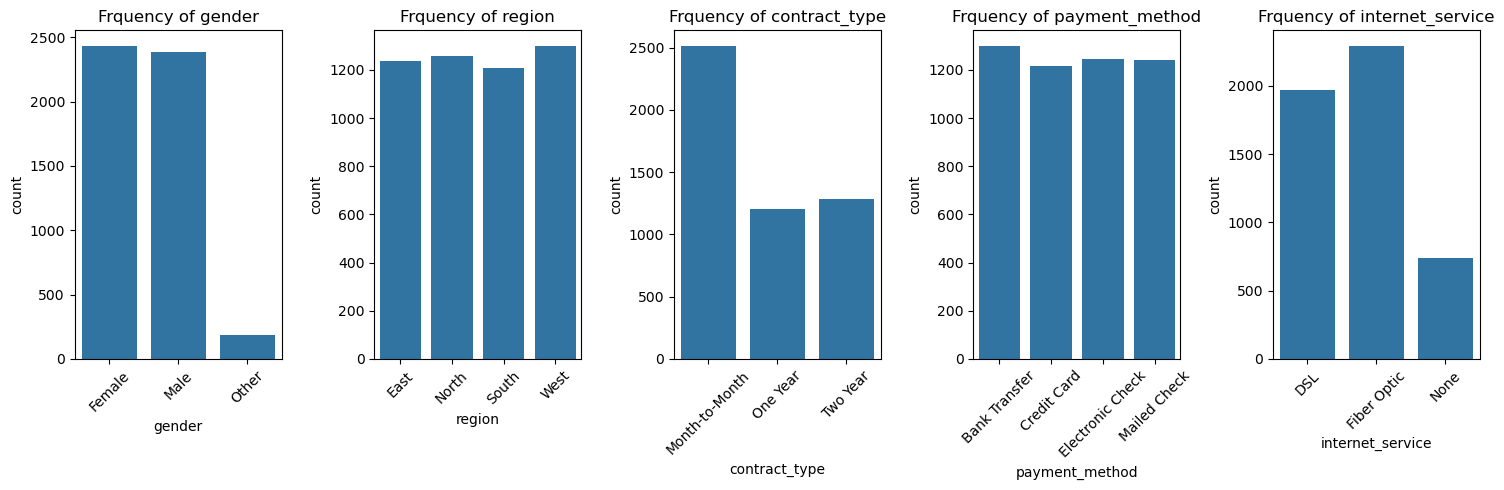

In [20]:
n_rows = 1
n_cols = math.ceil(len(cat_cols)/n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Frquency of {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Gender variable also has class imbalance: Category "Other" is very less(minority) compared to Femal and Male categpry

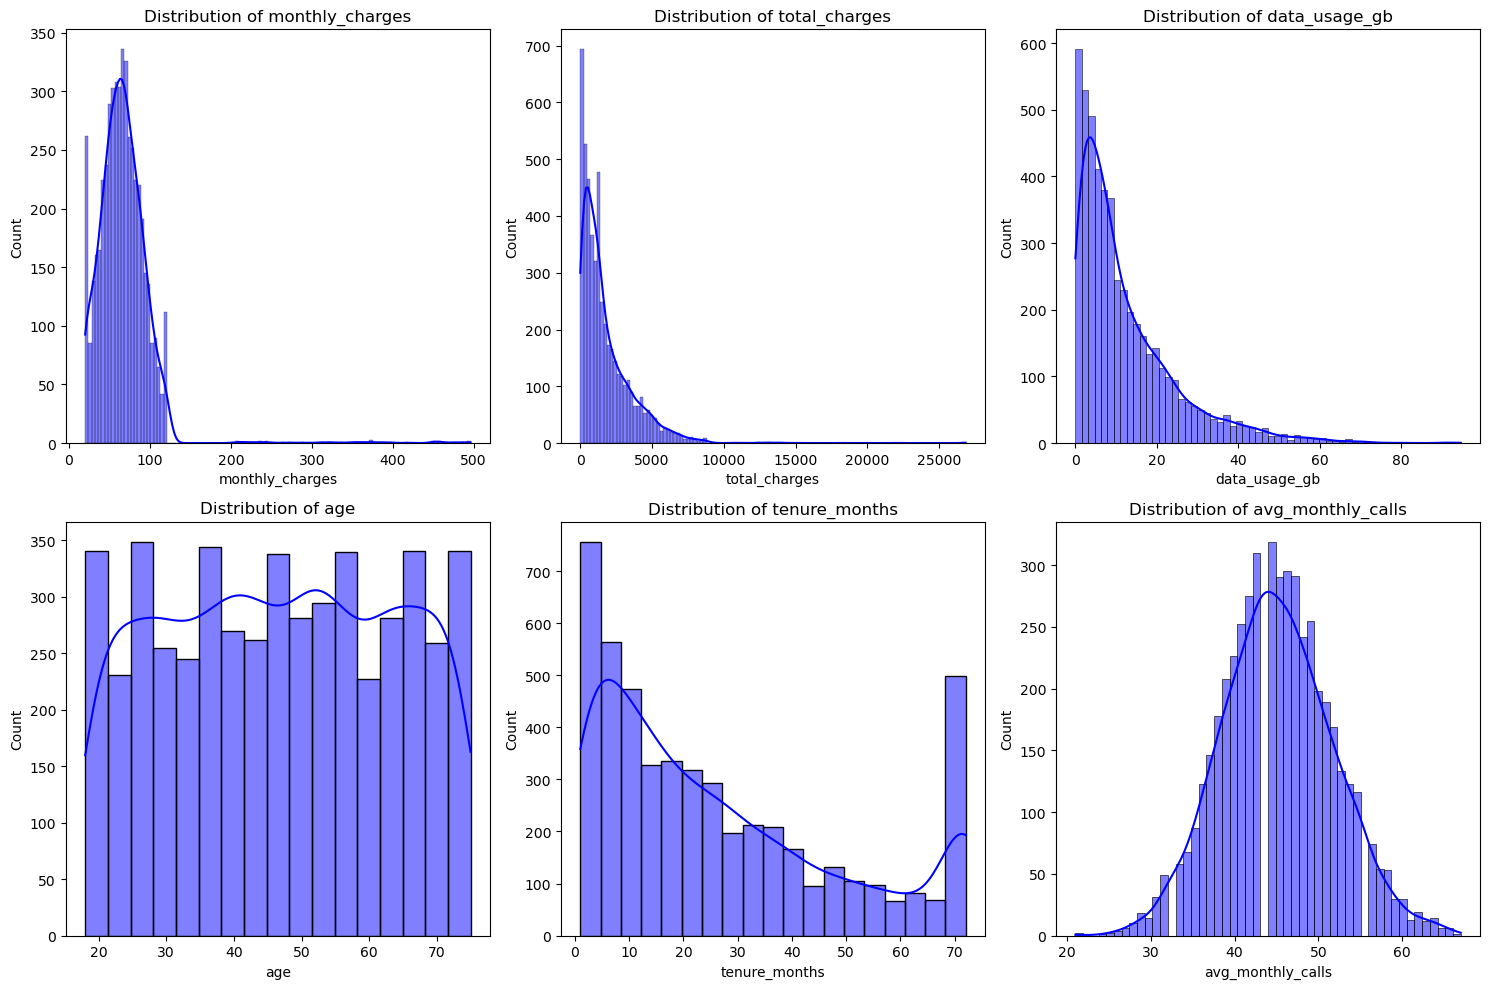

In [21]:
float_cols = df.select_dtypes('float').columns.to_list()

float_cols = float_cols + ['age','tenure_months','avg_monthly_calls']
float_cols

n_rows = 2
n_cols = math.ceil(len(float_cols) / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    # sns.histplot automatically adds the KDE line
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='blue')
    axes[i].set_title(f'Distribution of {col}')

# Hide any unused subplots (if float_cols is an odd number)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [22]:
summary_stats = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis':df[num_cols].kurtosis()
})
summary_stats

,Mean,Median,Skewness,Kurtosis
age,46.672800,47.000,-0.012929,-1.177615
senior_citizen,0.275400,0.000,1.005863,-0.988635
partner,0.544800,1.000,-0.179978,-1.968396
tenure_months,26.489000,20.000,0.805219,-0.545375
monthly_charges,67.209722,64.605,5.085265,48.275692
total_charges,1767.375144,1177.680,2.970096,21.389457
avg_monthly_calls,45.109200,45.000,0.124142,0.031966
data_usage_gb,12.259344,8.175,1.816773,4.113311
support_tickets,1.488200,1.000,0.776898,0.483292
streaming_tv,0.553200,1.000,-0.214079,-1.954952


**Insights**
1) Monthly_Charges: Right- Skewed indicating most customers falls in mid price range. Premium Users are rare.
2) Total_Charges: Highly Right Skewed, Many Customers have low total spends
3) Data_Usage_GB: Right Skewed, most customer consume low to moderate data
4) Age: follows Uniform Distribution, no biasnes
5) Tenure_Months: Right Skewed with spike near 70. Customer with long tenure_months are sticky and less likely to churn.
6) Avg_MOnthly_calls: Normal DIstribution. Values centre around Centre Mean

### Bivariant Analysis

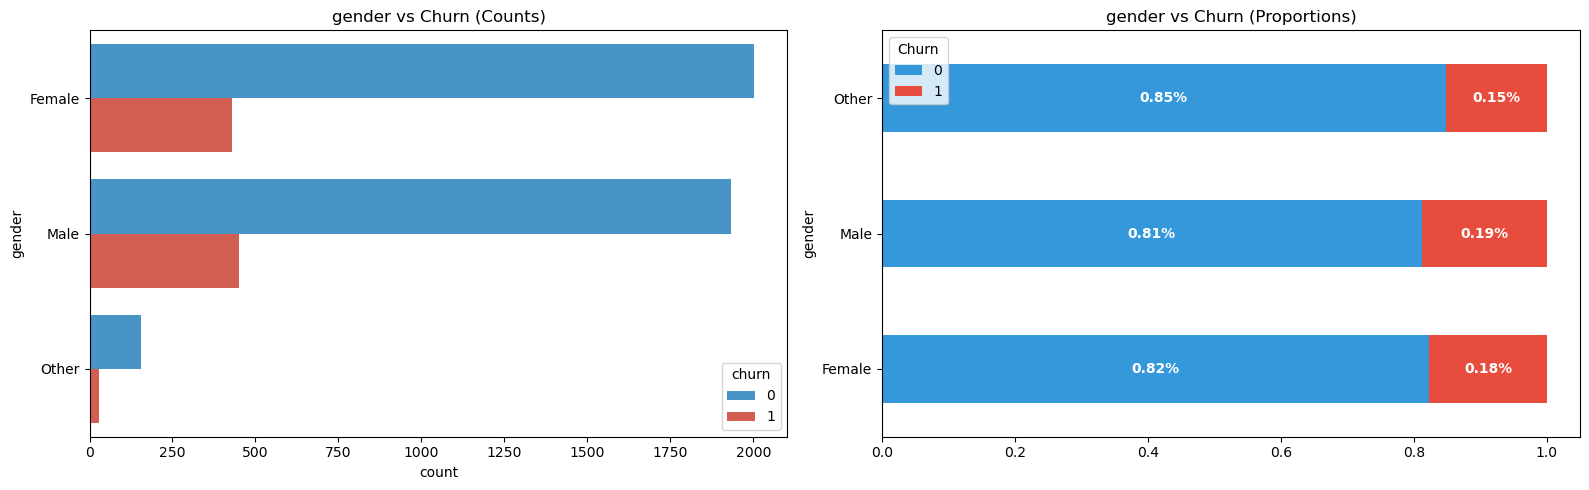

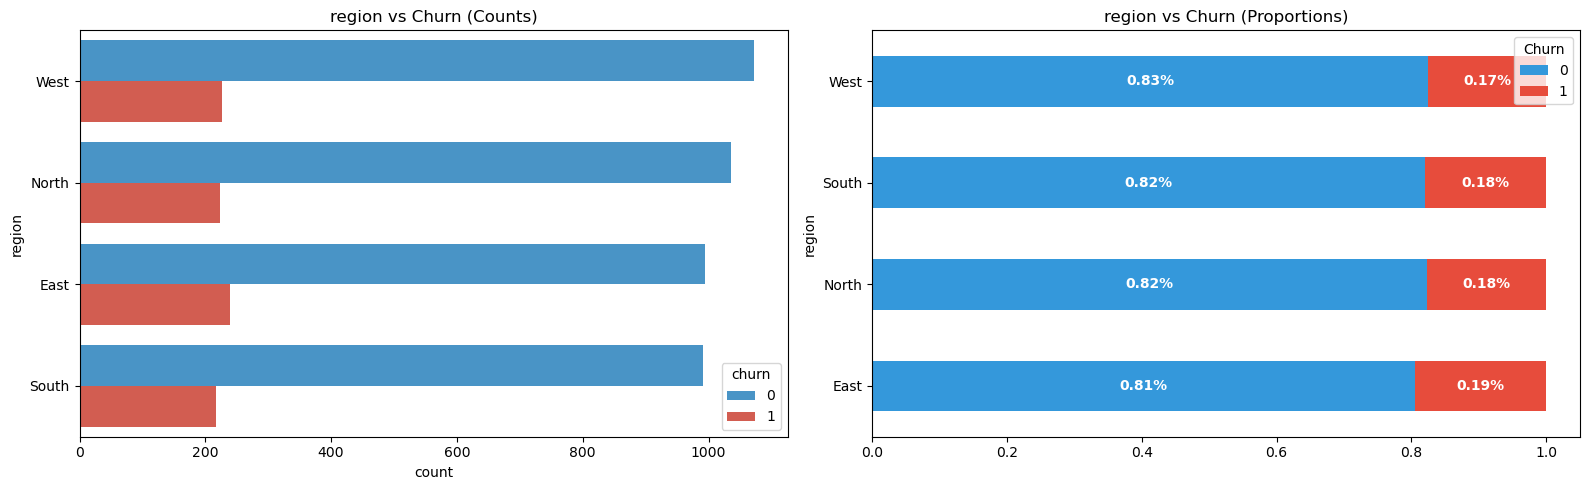

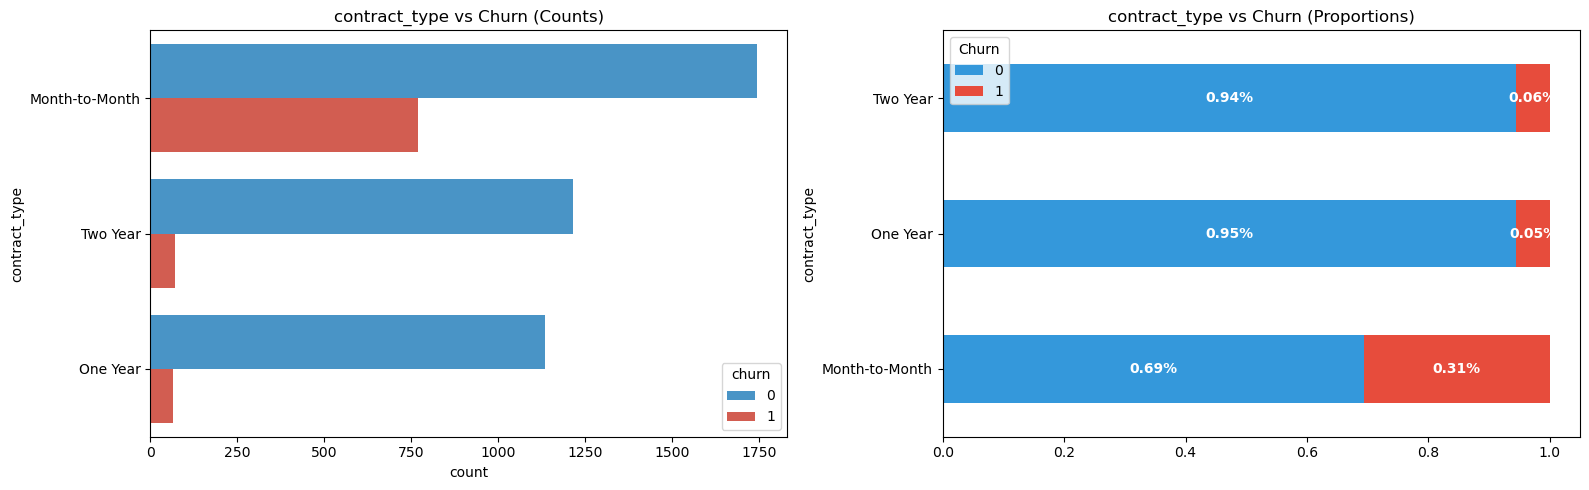

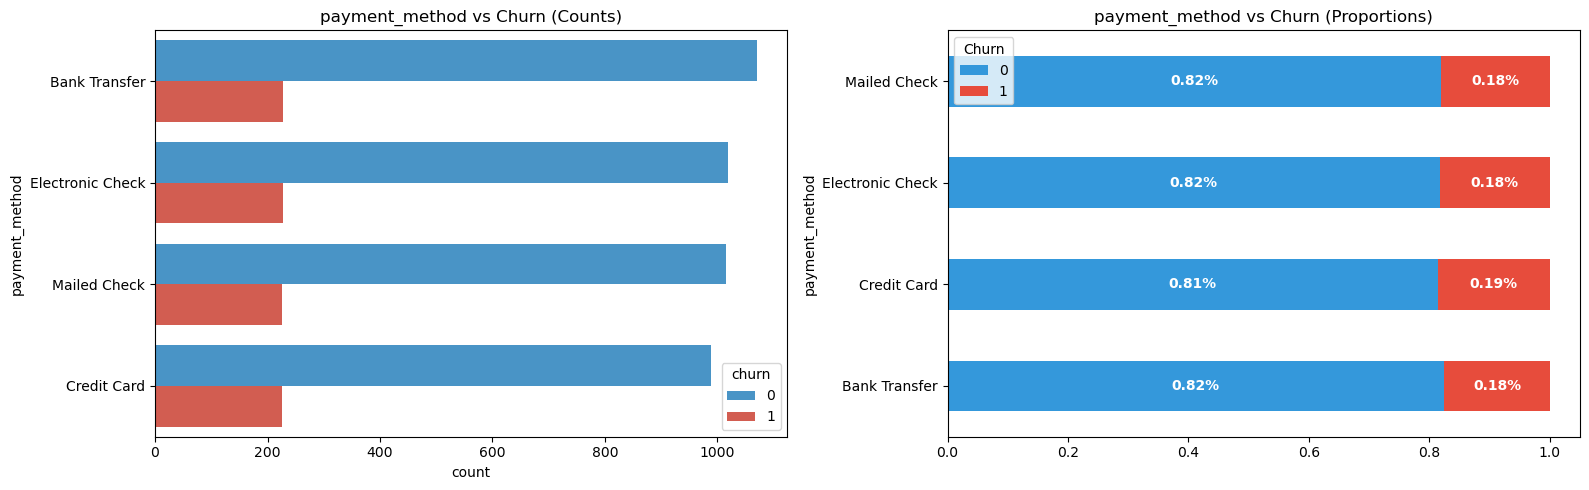

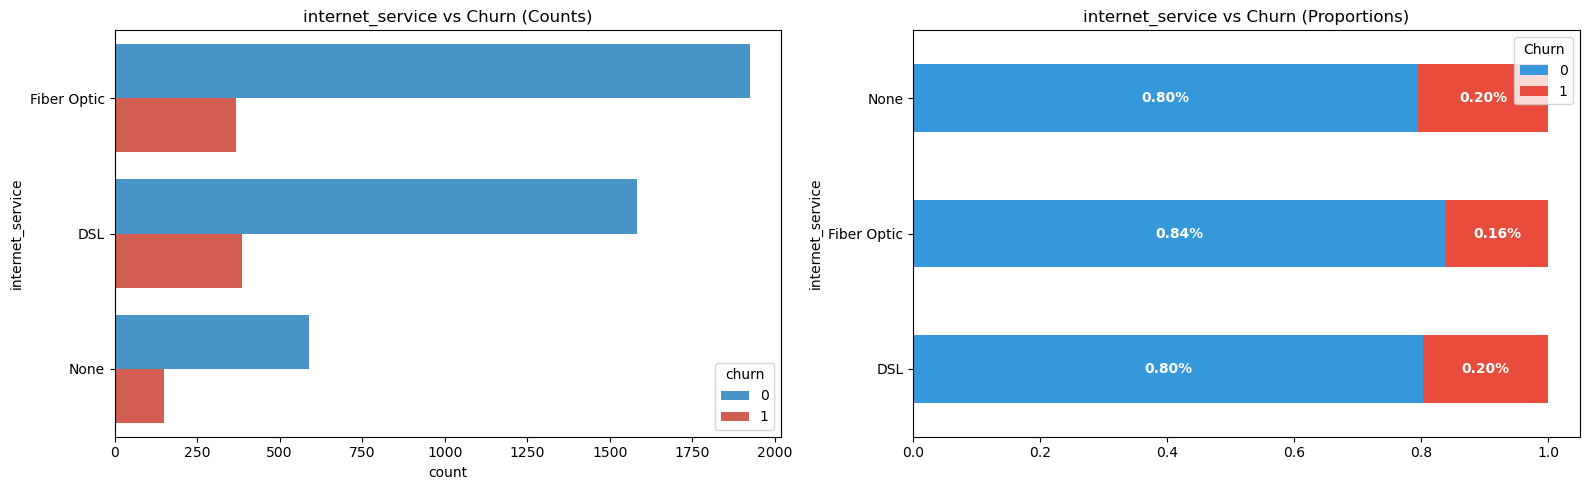

In [23]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Count plot split by target
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='churn', order=order, ax=axes[0],
                  palette=['#3498db', '#e74c3c'])
    axes[0].set_title(f'{col} vs Churn (Counts)')

    # Proportion plot
    ct = pd.crosstab(df[col], df['churn'], normalize='index')
    ct.plot(kind='barh', stacked=True, ax=axes[1], color=['#3498db', '#e74c3c'])
    axes[1].set_title(f'{col} vs Churn (Proportions)')
    axes[1].legend(title='Churn')

    # --- ADDING PERCENTAGE LABELS ---
    for container in axes[1].containers:
        # labels: multiplies decimal by 100 and adds % sign
        axes[1].bar_label(container, fmt='%.2f%%', label_type='center', color='white', weight='bold')

    plt.tight_layout()
    plt.show()

**Insights**
1) Contract-Type: Month-to-Month Customers has high curn rate (~30%). One-Year and Two-Year customers rarely churns.


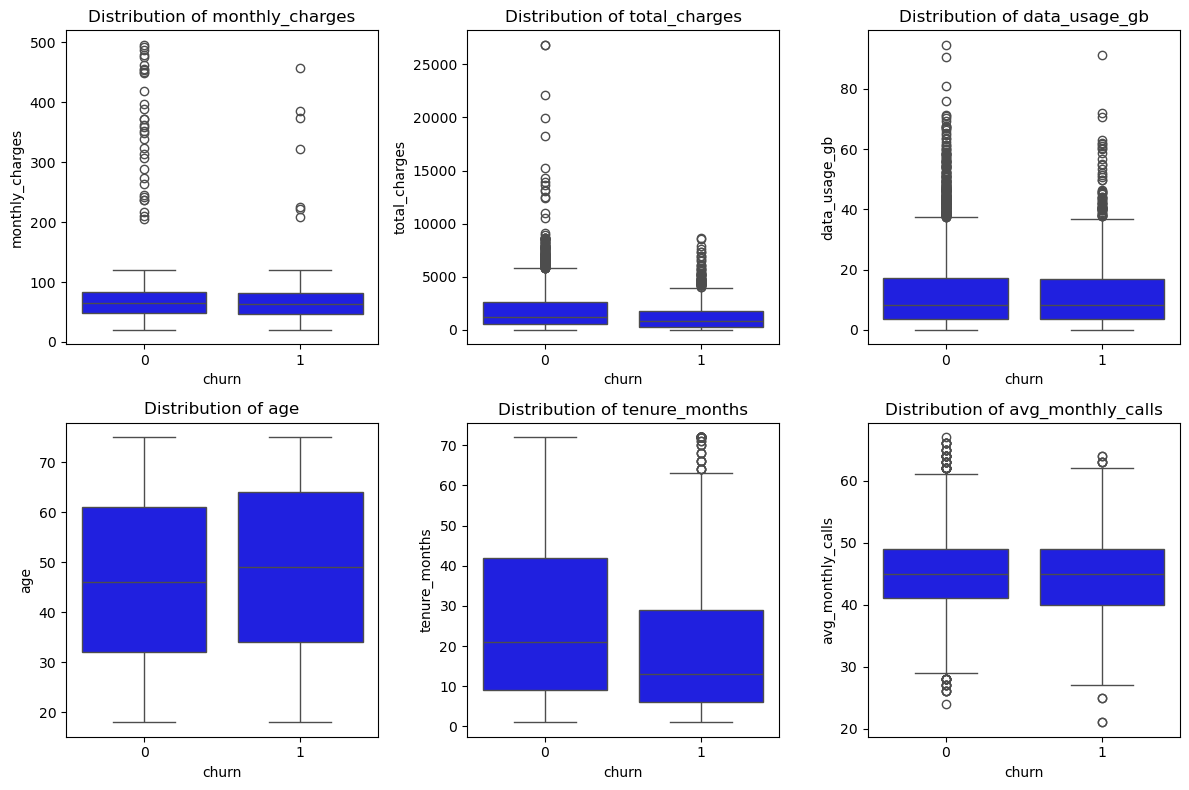

In [24]:
# Boxplot and Violin plot for each numeric feature by target
n_rows = 2
n_cols = math.ceil(len(float_cols) / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()



for i, col in enumerate(float_cols):
    # sns.histplot automatically adds the KDE line
    sns.boxplot(data=df, y=col,x='churn' , ax=axes[i], color='blue')
    axes[i].set_title(f'Distribution of {col}')

    
plt.tight_layout()
plt.show()

**Insights**
1) Tenure_Months - Customers having less median tenure_months are more likely to churn
2) Total_Charges - Customers who spends are less likely to churn. They are low lifetime value customers

### Multivariant Analysis

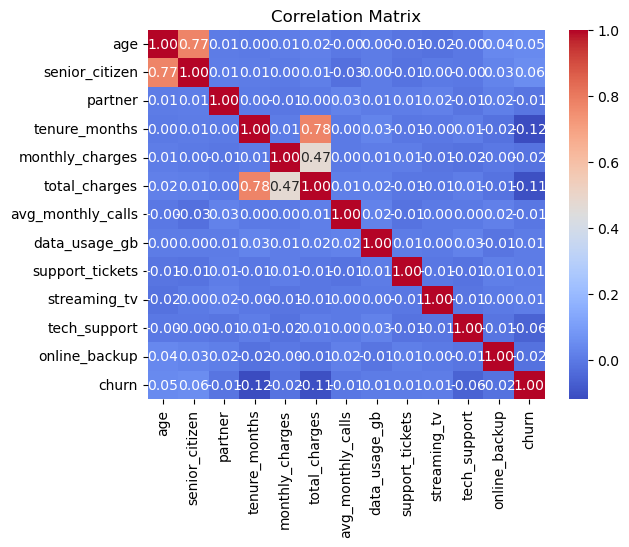

In [25]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Insights**
1) Tenure_Months has negative correlation (-0.12) indicating Longer tenure are less likely to churn.
2) Total_charges has negative correlation (-0.11) indicating High value customers are more likely to stay.
3) Total_Charges and tenure_months show strong correlation (0.78), the longer a customer stays, the higher their cumulative costs become. They also exhibit structural relationship and can cause multicollinearity amongst them as total_cost = tenure_month * tenure
4) Age and Senior Citizen are highly correleted.

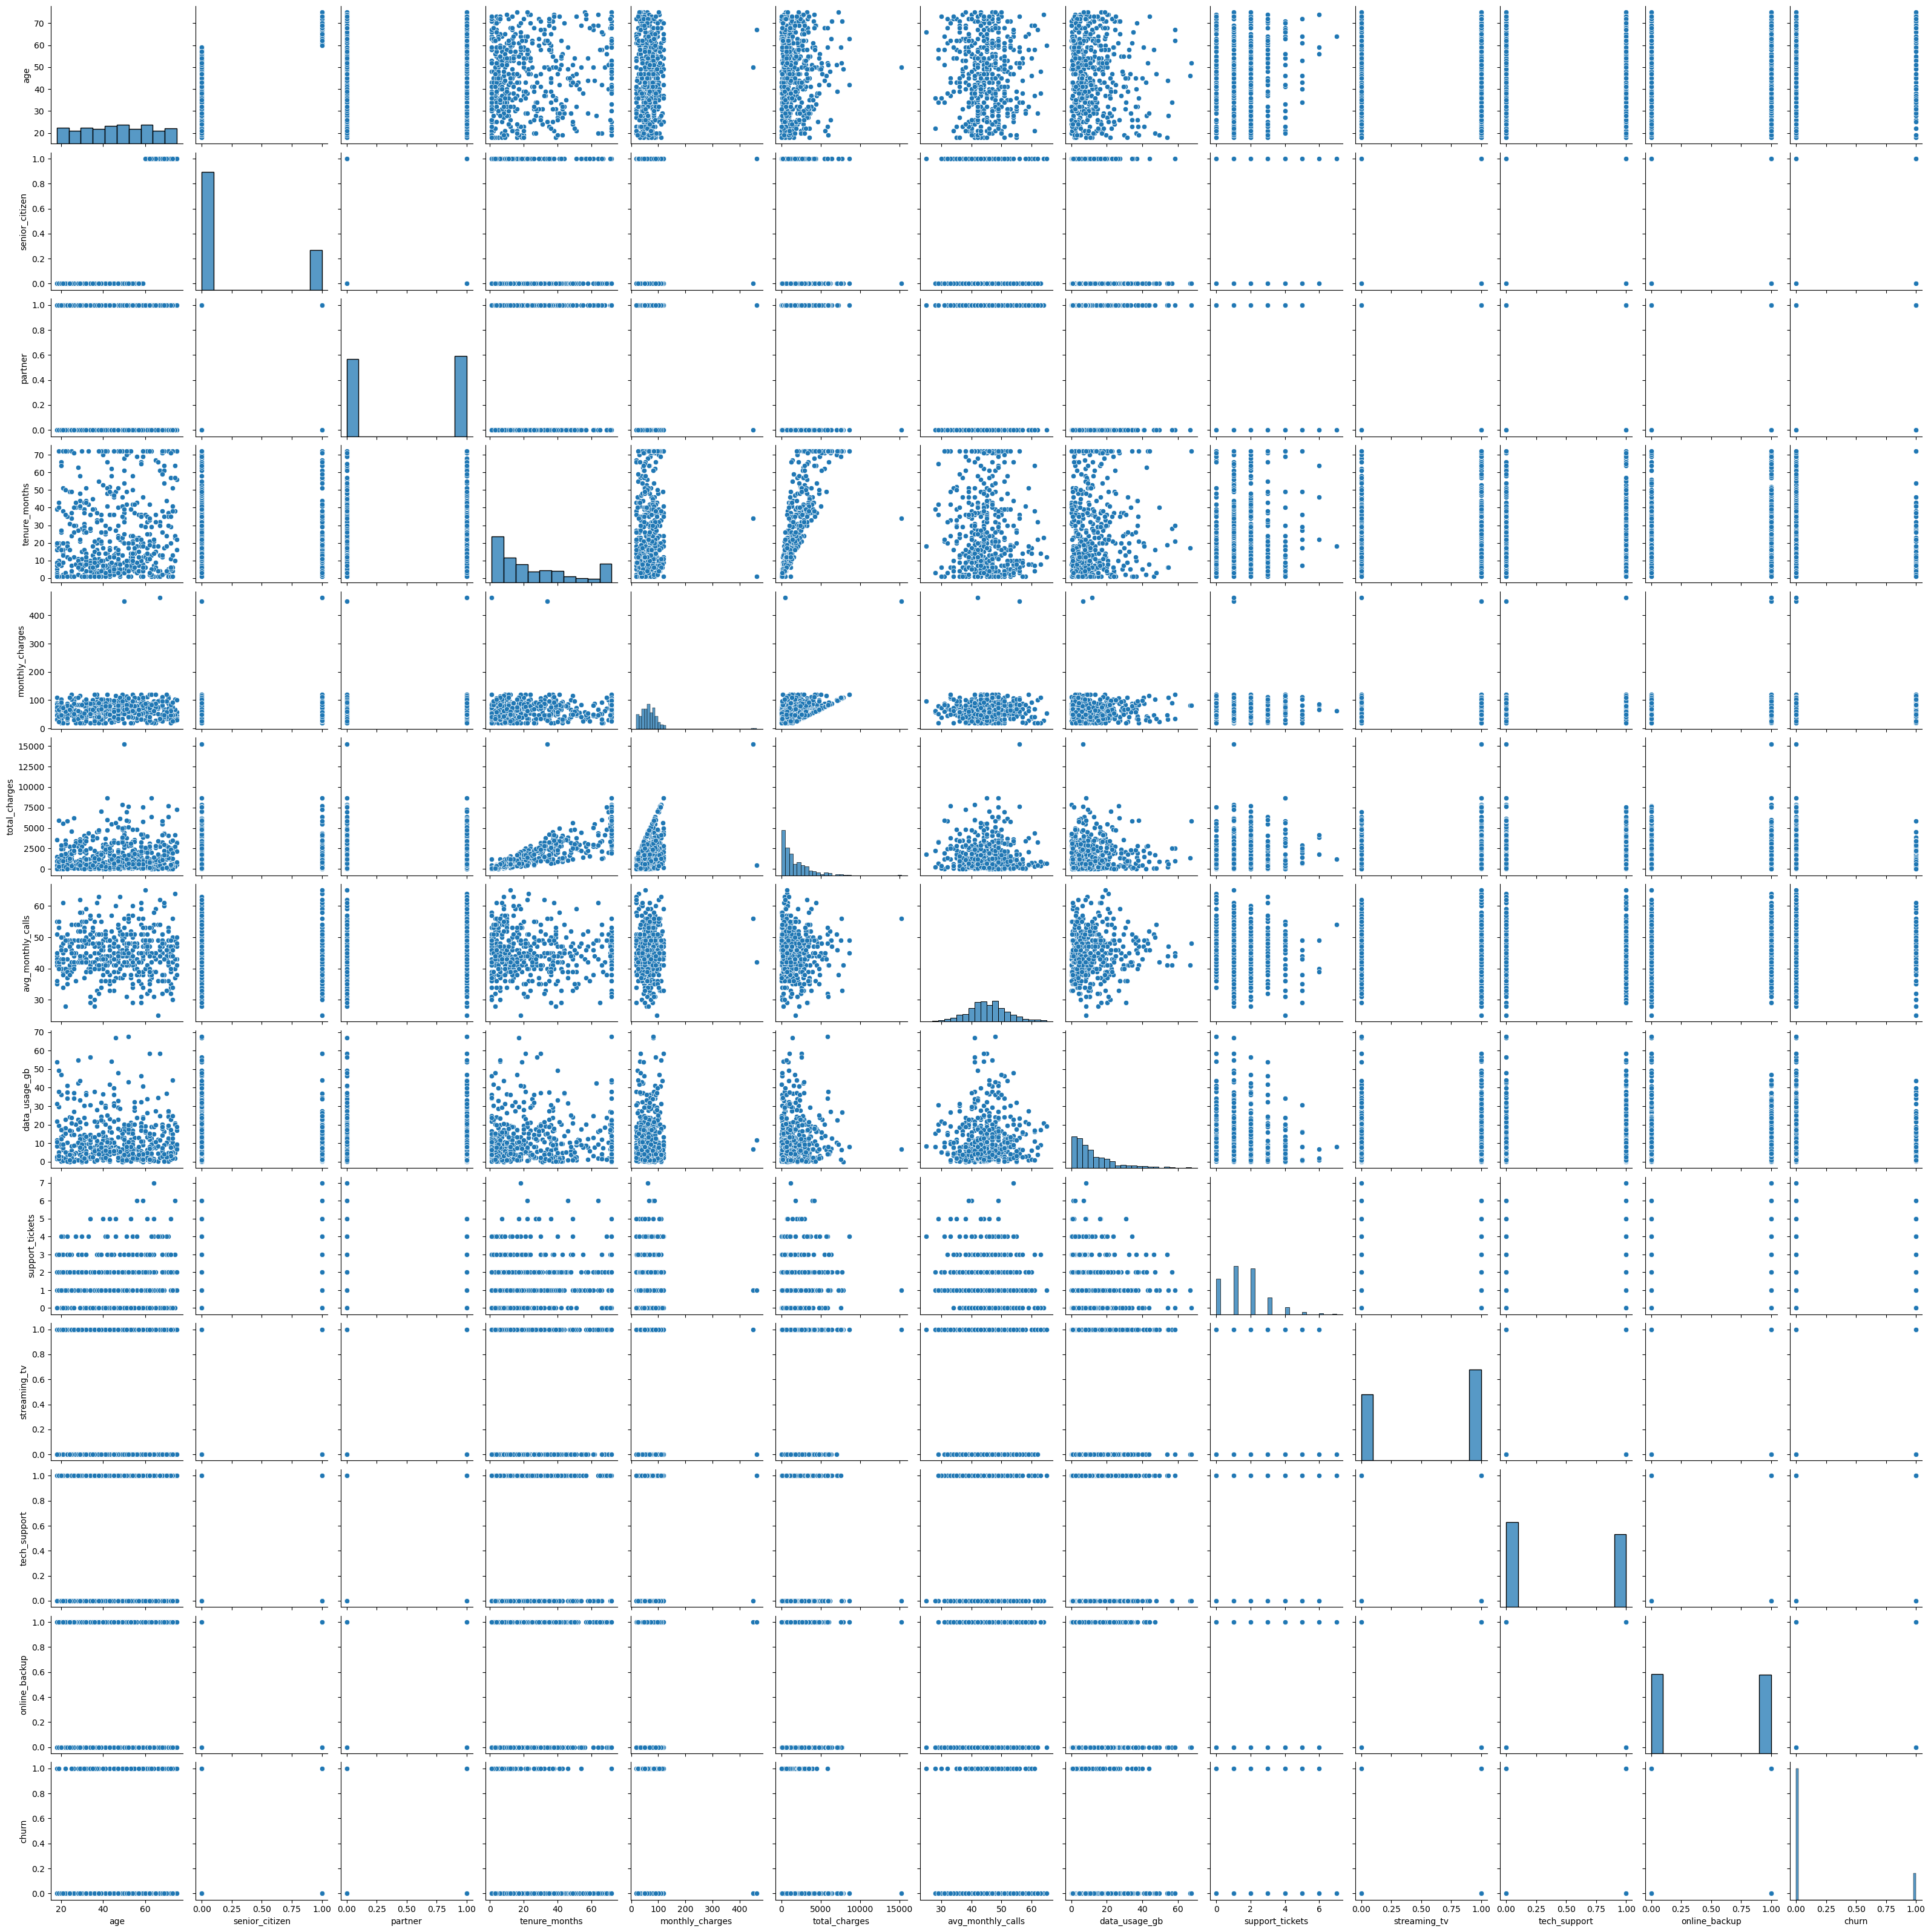

In [26]:
sns.pairplot(df[num_cols].sample(min(500, len(df))))
plt.show()

### Feature Engineering

**Outliers Detection and COrrection**

In [27]:
df['churn'].value_counts()

churn
0    4093
1     907
Name: count, dtype: int64

In [28]:
def cap_outliers(df, columns=None):
    """
    Caps outliers using the IQR method and rounds values to 1 decimal place.
    """
    # If no columns are specified, target all numerical columns
    if columns is None:
        columns = df.select_dtypes(include='number').drop('churn', axis=1).columns

    for col in columns:
        # iqr and bounds calculation
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        low_bound = q1 - 1.5 * iqr
        high_bound = q3 + 1.5 * iqr

        # cap outliers
        df[col] = np.where(df[col] < low_bound, low_bound, df[col])
        df[col] = np.where(df[col] > high_bound, high_bound, df[col])

        # rounding
        df[col] = df[col].round(1)
        
    return df

In [29]:
df = cap_outliers(df)

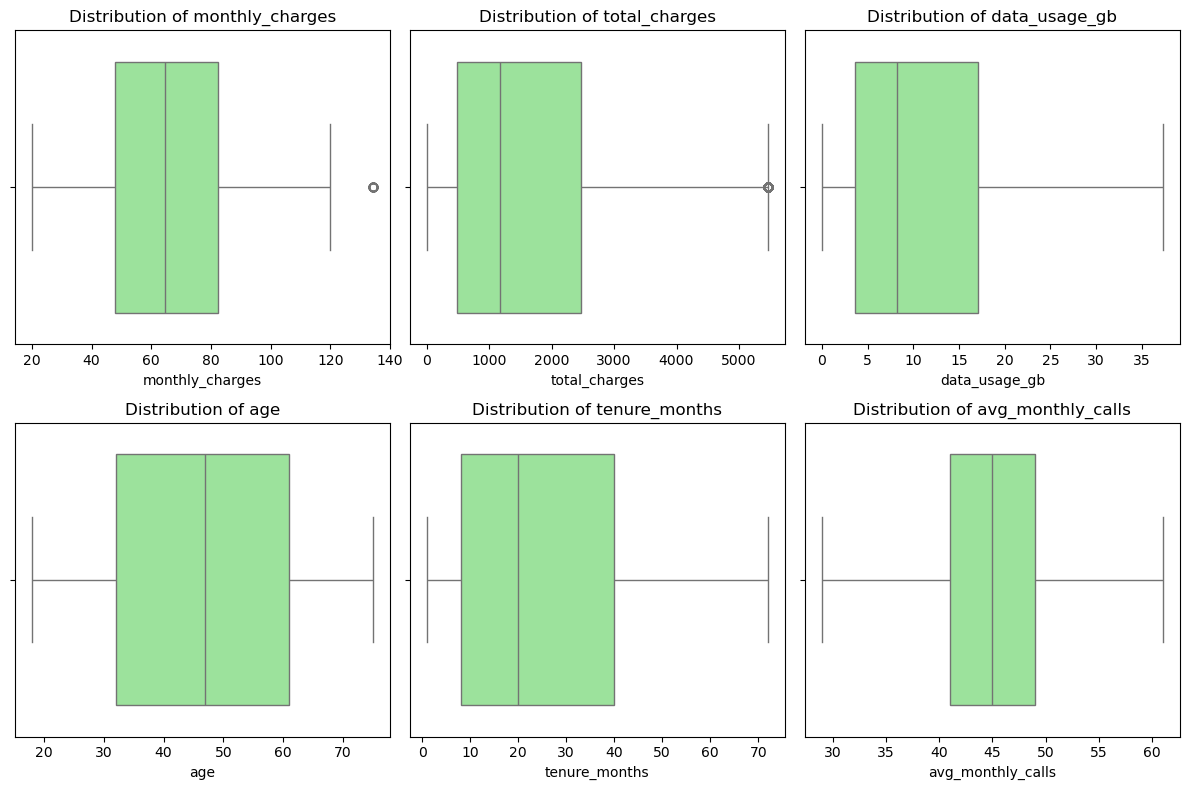

In [30]:
#checking if outliers are removed or not
n_rows = 2
n_cols = math.ceil(len(float_cols) / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()



for i, col in enumerate(float_cols):
    # sns.histplot automatically adds the KDE line
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Distribution of {col}')

    
plt.tight_layout()
plt.show()

In [31]:
df['churn'].value_counts()

churn
0    4093
1     907
Name: count, dtype: int64

We can observe that all the outliers are remove. Hardly one or two datapoints are remaining.

In [32]:
# Categoring tenurue months into group of 12
df['tenure_months_group'] = pd.cut(df['tenure_months'],bins=[0,12,24,48,72],labels=['new','early','mid','loyal'])
df.head()

,customer_id,age,gender,region,senior_citizen,partner,tenure_months,contract_type,payment_method,internet_service,monthly_charges,total_charges,avg_monthly_calls,data_usage_gb,support_tickets,streaming_tv,tech_support,online_backup,churn,tenure_months_group
0,CUST665822,56.0,Male,East,0.0,0.0,40.0,One Year,Bank Transfer,None,48.6,1969.3,54.0,7.0,0.0,1.0,0.0,1.0,0,mid
1,CUST327221,69.0,Female,North,1.0,0.0,47.0,Month-to-Month,Electronic Check,DSL,20.0,1177.7,45.0,37.2,1.0,0.0,1.0,0.0,0,mid
2,CUST805684,46.0,Other,North,0.0,1.0,15.0,Month-to-Month,Credit Card,Fiber Optic,94.7,1389.0,45.0,5.8,3.5,0.0,1.0,0.0,1,early
3,CUST085472,32.0,Female,East,0.0,1.0,15.0,Two Year,Electronic Check,Fiber Optic,65.4,956.6,40.0,3.3,1.0,1.0,0.0,0.0,0,early
4,CUST568785,60.0,Female,East,1.0,1.0,72.0,One Year,Electronic Check,None,63.8,4617.3,33.0,13.6,2.0,1.0,0.0,0.0,0,loyal


tenure_group: Buckets tenure into lifecycle stages. During EDA we observe customers having longer tenure_groups are more loyal and less likely to churn.

In [33]:

# Aggregating the services horizontally to count the number of services. More services less change of churn
service_cols = ["streaming_tv", "tech_support", "online_backup"]
df["services_count"] = df[service_cols].sum(axis=1)

More services → higher switching cost → lower churn propensity. Aggregation also reduces multicollinearity among the three binary flags.

In [34]:
#High Risk Flag - Intersection of Month-to-Month contract, Electronic Check payment, and zero add-on services
df["high_risk_flag"] = ((df["contract_type"] == "Month-to-Month") &(df["payment_method"] == "Electronic Check") & 
                        (df["services_count"] == 0)).astype(int)


The intersection of Month-to-Month contract, Electronic Check payment, and zero add-on services defines the canonical high-churn segment intelecoms literature. Creating an explicit flag lets any model exploit this three-way interaction

In [35]:
df.head()

,customer_id,age,gender,region,senior_citizen,partner,tenure_months,contract_type,payment_method,internet_service,...,avg_monthly_calls,data_usage_gb,support_tickets,streaming_tv,tech_support,online_backup,churn,tenure_months_group,services_count,high_risk_flag
0,CUST665822,56.0,Male,East,0.0,0.0,40.0,One Year,Bank Transfer,None,...,54.0,7.0,0.0,1.0,0.0,1.0,0,mid,2.0,0
1,CUST327221,69.0,Female,North,1.0,0.0,47.0,Month-to-Month,Electronic Check,DSL,...,45.0,37.2,1.0,0.0,1.0,0.0,0,mid,1.0,0
2,CUST805684,46.0,Other,North,0.0,1.0,15.0,Month-to-Month,Credit Card,Fiber Optic,...,45.0,5.8,3.5,0.0,1.0,0.0,1,early,1.0,0
3,CUST085472,32.0,Female,East,0.0,1.0,15.0,Two Year,Electronic Check,Fiber Optic,...,40.0,3.3,1.0,1.0,0.0,0.0,0,early,1.0,0
4,CUST568785,60.0,Female,East,1.0,1.0,72.0,One Year,Electronic Check,None,...,33.0,13.6,2.0,1.0,0.0,0.0,0,loyal,1.0,0


In [36]:
#dropping customer id
df.drop(columns=['customer_id'],inplace=True)

In [37]:
df.head(1)

,age,gender,region,senior_citizen,partner,tenure_months,contract_type,payment_method,internet_service,monthly_charges,...,avg_monthly_calls,data_usage_gb,support_tickets,streaming_tv,tech_support,online_backup,churn,tenure_months_group,services_count,high_risk_flag
0,56.0,Male,East,0.0,0.0,40.0,One Year,Bank Transfer,None,48.6,...,54.0,7.0,0.0,1.0,0.0,1.0,0,mid,2.0,0


In [38]:
# Sepeating Features and target
target = 'churn'
X = df.drop(columns=[target])
y = df[target]

In [39]:
df.select_dtypes(include=['int','float']).columns.tolist()

['age',
 'senior_citizen',
 'partner',
 'tenure_months',
 'monthly_charges',
 'total_charges',
 'avg_monthly_calls',
 'data_usage_gb',
 'support_tickets',
 'streaming_tv',
 'tech_support',
 'online_backup',
 'churn',
 'services_count',
 'high_risk_flag']

In [40]:
df.columns

Index(['age', 'gender', 'region', 'senior_citizen', 'partner', 'tenure_months',
       'contract_type', 'payment_method', 'internet_service',
       'monthly_charges', 'total_charges', 'avg_monthly_calls',
       'data_usage_gb', 'support_tickets', 'streaming_tv', 'tech_support',
       'online_backup', 'churn', 'tenure_months_group', 'services_count',
       'high_risk_flag'],
      dtype='object')

In [41]:
#creating variable to store category column for doing onehot encoding and label encoding
ohe_cols = ['gender','region','contract_type','payment_method','internet_service']
le_cols = ['tenure_months_group']
num_cols = ['age','senior_citizen','partner','tenure_months','monthly_charges','total_charges','avg_monthly_calls',
            'data_usage_gb','support_tickets','streaming_tv','tech_support','online_backup','services_count','high_risk_flag']


In [42]:
#checking shape of of dependent and target variable
X.shape,y.shape

((5000, 20), (5000,))

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [44]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((4000, 20), (1000, 20), (4000,), (1000,))

In [45]:
# creating column transformer pipeline for encoding and normalizing numeralical data
num_pipeline = Pipeline([('scaler', StandardScaler())])
num_pipeline

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [46]:
#creating column transformer pipeline for one hot encoding
nominal_pipeline = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
nominal_pipeline

,steps,"[('onehot', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


In [47]:
#creating column transformr pipeline for label encoding
ordinal_pipeline = Pipeline([('ordinal', OrdinalEncoder(categories=[['new','early','mid','loyal']]))])
ordinal_pipeline

,steps,"[('ordinal', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,"[['new', 'early', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [48]:
#combining all column transformer pipeline
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('nominal', nominal_pipeline, ohe_cols),
    ('ordinal', ordinal_pipeline, le_cols)
])
preprocessor

,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Training Model

In [49]:
# Defining Evaluation Function
def evaluate(y_test, y_pred, y_prob, threshold=None):
    '''
    Enhanced Model Evaluation:
    - F1 Score
    - ROC-AUC
    - Confusion Matrix
    - Classification Report
    - ROC Curve
    - Precision-Recall Curve

    Params:
    y_test : actual labels
    y_pred : predicted labels (optional if threshold used)
    y_prob : predicted probabilities
    threshold : optional threshold to override y_pred
    '''

    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import (
        f1_score, roc_auc_score, confusion_matrix,
        classification_report, RocCurveDisplay,
        precision_recall_curve, average_precision_score
    )

    # 🔹 Apply custom threshold if provided
    if threshold is not None:
        y_pred = (y_prob >= threshold).astype(int)
        print(f"\nUsing custom threshold: {threshold}")

    # 🔹 Metrics
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # 🔹 ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title("ROC Curve")
    plt.show()

    # 🔹 Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)

    plt.figure()
    plt.plot(recall, precision, label=f"PR Curve (AP = {ap_score:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid()
    plt.show()

**Logistic Regression**

In [50]:
# Defining LogisticRegression Pipeline 
lr_pipeline = Pipeline([('preprocessor',preprocessor),
                        #('smote', SMOTE(random_state=42))
                        ('model',LogisticRegression(class_weight='balanced'))])
lr_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
# Defining LR Parameters
lr_param = {
    'model__C': uniform(0.01, 10),
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

In [52]:
# Tuning Hyperparameter
lr_model = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=lr_param,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [53]:
#training Logistic Regression model
lr_model.fit(X_train,y_train)

,estimator,Pipeline(step...'balanced'))])
,param_distributions,"{'model__C': <scipy.stats....0019D554B6BA0>, 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [54]:
#finding best parameter for Logistic Regression model
lr_model_best = lr_model.best_estimator_
lr_model_best

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


===== Logistic Regression =====
F1 Score: 0.4371941272430669
ROC-AUC: 0.756143794817828

Confusion Matrix:
 [[521 298]
 [ 47 134]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.64      0.75       819
           1       0.31      0.74      0.44       181

    accuracy                           0.66      1000
   macro avg       0.61      0.69      0.59      1000
weighted avg       0.81      0.66      0.69      1000



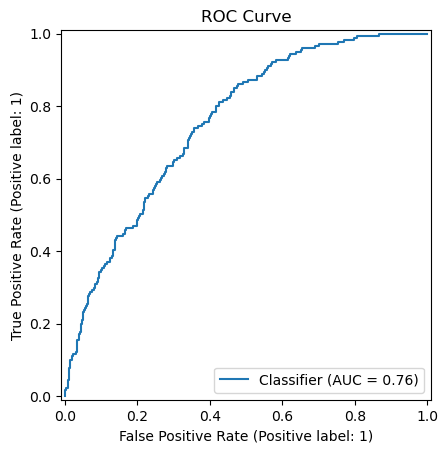

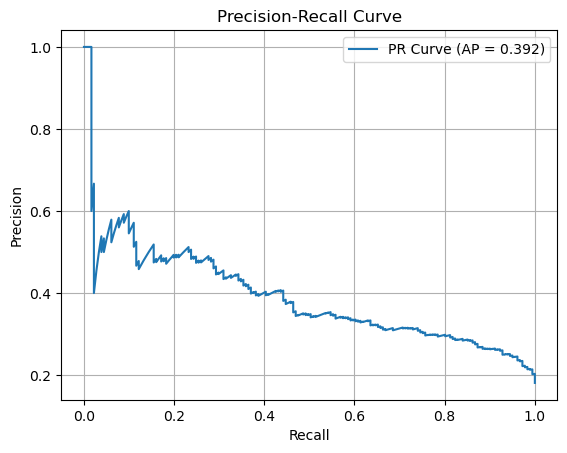

In [55]:
#predicting and evaluation
y_pred_lr = lr_model_best.predict(X_test)
y_prob_lr = lr_model_best.predict_proba(X_test)[:, 1]

print("===== Logistic Regression =====")
evaluate(y_test, y_pred_lr, y_prob_lr)

**RandomForest**

In [56]:
# Defining Random Forest Pipeline 
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    #("smote", SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42,class_weight='balanced'))
])

rf_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
#define parameters to do hypertune using RandomSearch
rf_param = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 5)
}

rf_param

{'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x19d58a59940>,
 'model__max_depth': [None, 5, 10, 20],
 'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x19d652b5590>,
 'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x19d652b5810>}

In [58]:
# Tuning Hyperparameter
rf_model = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param,
    n_iter=25,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)



In [59]:
#training model
rf_model.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': <scipy.stats....0019D652B5810>, 'model__min_samples_split': <scipy.stats....0019D652B5590>, 'model__n_estimators': <scipy.stats....0019D58A59940>}"
,n_iter,25
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [60]:
#finding best parameter for Random Forest model
rf_model_best = rf_model.best_estimator_
rf_model_best

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
#predicting on test variable
y_pred_rf = rf_model_best.predict(X_test)
y_prob_rf = rf_model_best.predict_proba(X_test)[:,1] #giving probabilities for class 1 that is churning

y_pred_rf[:5],y_prob_rf[:5]

(array([0, 0, 0, 1, 0]),
 array([0.3365336 , 0.2359346 , 0.26677384, 0.5900597 , 0.14736986]))

===== Random Forest =====
F1 Score: 0.43219076005961254
ROC-AUC: 0.7554827002340814

Confusion Matrix:
 [[474 345]
 [ 36 145]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.58      0.71       819
           1       0.30      0.80      0.43       181

    accuracy                           0.62      1000
   macro avg       0.61      0.69      0.57      1000
weighted avg       0.81      0.62      0.66      1000



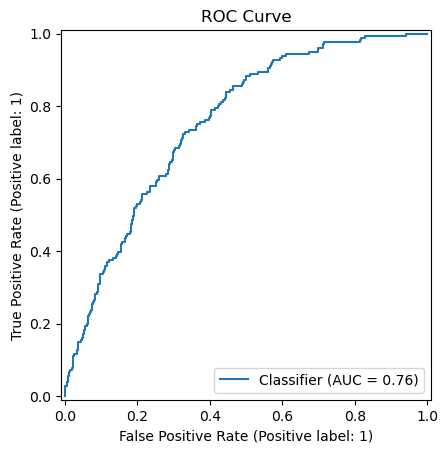

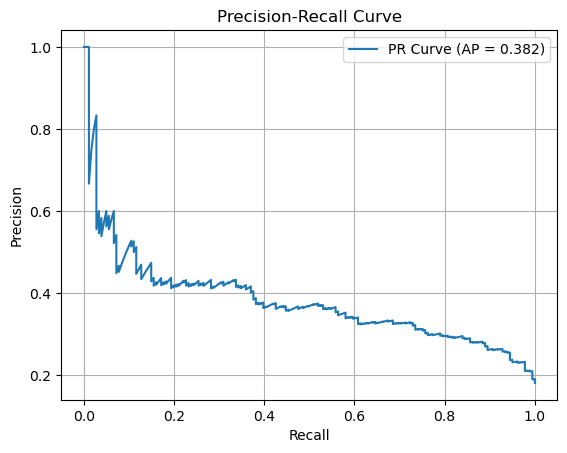

In [62]:
#printing evaluation of random forest
print("===== Random Forest =====")
evaluate(y_test, y_pred_rf, y_prob_rf)

**XgBoost**

In [63]:
# Computing class ratio
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale_pos_weight:", ratio)

Scale_pos_weight: 4.509641873278237


In [64]:
#creating xgb classifier pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    #("smote", SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='logloss',scale_pos_weight=ratio))
                            #scale_pos_weight=ratio))
])

In [65]:
#defining hyperparameters for finetuning it
xgb_param = {
    'model__n_estimators': randint(100, 400),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4)
}

In [66]:
#finetining XGB Classifier hyperparameters
xgb_model = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param,
    n_iter=25,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [67]:
#training model
xgb_model.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': <scipy.stats....0019D55686650>, 'model__learning_rate': <scipy.stats....0019D653B2E90>, 'model__max_depth': <scipy.stats....0019D554B3A80>, 'model__n_estimators': <scipy.stats....0019D554B2C40>, ...}"
,n_iter,25
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [68]:
#finding best parameter for XGBClassifier
xgb_model_best = xgb_model.best_estimator_
xgb_model_best

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
#predicting on test variable
y_pred_xgb = xgb_model_best.predict(X_test)
y_prob_xgb = xgb_model_best.predict_proba(X_test)[:, 1]

y_pred_xgb[:5],y_prob_xgb[:5]


(array([0, 0, 0, 1, 0]),
 array([0.31225967, 0.24915099, 0.3068834 , 0.59997207, 0.10671971],
       dtype=float32))

===== XGBoost =====
F1 Score: 0.4331395348837209
ROC-AUC: 0.7562078805172726

Confusion Matrix:
 [[461 358]
 [ 32 149]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.56      0.70       819
           1       0.29      0.82      0.43       181

    accuracy                           0.61      1000
   macro avg       0.61      0.69      0.57      1000
weighted avg       0.82      0.61      0.65      1000



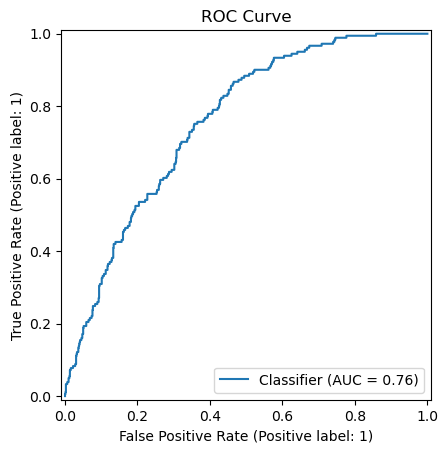

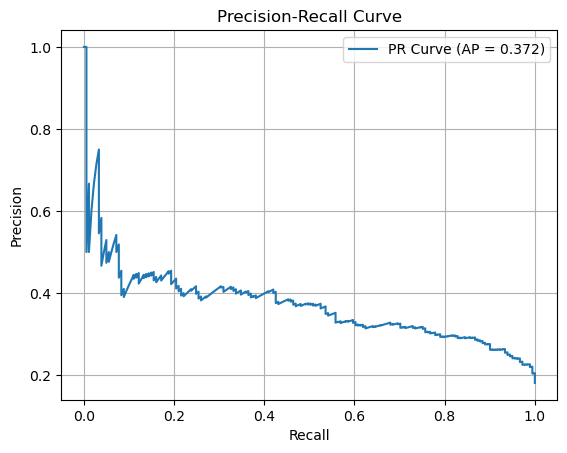

In [70]:
# evaluting the model
print("===== XGBoost =====")
evaluate(y_test, y_pred_xgb, y_prob_xgb)

## Model Performance Comparison (Churn Prediction)

| Model                | F1  | Recall | Precision | AUC  | AP (PR Score) |
|---------------------|-----|--------|-----------|------|----------------|
| Logistic Regression | 0.44 | 0.74   | 0.31      | 0.76 | 0.392          |
| Random Forest       | 0.43 | 0.80   | 0.30      | 0.75 | 0.382          |
| XGBoost             | 0.43 | 0.82   | 0.29      | 0.76 | 0.372          |

1) All three models show similar ROC AUC (~0.75–0.76), which suggests they perform similarly in overall ranking ability. However, ROC AUC can be misleading in imbalanced problems like churn because it is influenced heavily by the majority class. 
2) The Precision–Recall (PR) curve provides a clearer picture, as it focuses on correctly identifying churners. Here, Logistic Regression performs best with the highest Average Precision (0.392), followed by Random Forest (0.382), and XGBoost (0.372). This indicates that while ROC suggests similar performance, PR reveals that Logistic Regression is actually better at identifying churn customers effectively.
3) XGBoost has Highest recall (0.82) and accept more false positives. High Recall means you captured more chunners. If the gaol is to capture maximum churn capture then XGBoost is preferred.
4) Precision is low for all the models indicating higher cost for business cost for retaining customer. Low precision means the model incorrectly flags many non-churn customers, leading to unnecessary marketing spend on customers who would not have churned. 
   Eg: Precision(for churn = 1): For Random Forest Model is 0.30. That means out of 100 customers that are likely to churn, 30 customers actually churned, 70 are false alarms. These false alarms are wasted spend

In [71]:
df.head(1)

,age,gender,region,senior_citizen,partner,tenure_months,contract_type,payment_method,internet_service,monthly_charges,...,avg_monthly_calls,data_usage_gb,support_tickets,streaming_tv,tech_support,online_backup,churn,tenure_months_group,services_count,high_risk_flag
0,56.0,Male,East,0.0,0.0,40.0,One Year,Bank Transfer,None,48.6,...,54.0,7.0,0.0,1.0,0.0,1.0,0,mid,2.0,0


In [72]:
df.to_csv('churn_preprocessed.csv',index=False)

In [73]:
df.columns

Index(['age', 'gender', 'region', 'senior_citizen', 'partner', 'tenure_months',
       'contract_type', 'payment_method', 'internet_service',
       'monthly_charges', 'total_charges', 'avg_monthly_calls',
       'data_usage_gb', 'support_tickets', 'streaming_tv', 'tech_support',
       'online_backup', 'churn', 'tenure_months_group', 'services_count',
       'high_risk_flag'],
      dtype='object')

In [75]:
from feature_engineering import Feature_Engineering

In [102]:
rf_pipeline = Pipeline([
    ("fe", Feature_Engineering()),
    ("preprocessing", ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("nominal", nominal_pipeline, ohe_cols),
    ("ordinal", ordinal_pipeline, le_cols)
])),
    ("model", RandomForestClassifier())
])

In [103]:
rf_pipeline.fit(X_train,y_train)

,steps,"[('fe', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
def churn_predict(input_data, model):
    """
    input_data: dict (raw user input)
    model: trained pipeline
    """
    
    # Convert input to DataFrame
    df = pd.DataFrame([input_data])

    #fe = Feature_Engineering()
    #df = fe.transform(df)

    # ---- Step 2: Apply preprocessing (encoding/scaling) ----
   # df_processed = preprocessor.transform(df)
    
    # Predict using pipeline (feature engineering happens inside)
    prob = model.predict_proba(df)[0][1]  # probability of churn
    pred = model.predict(df)[0]
    
    return {"probability": round(prob, 4),"prediction": int(pred)}

In [107]:
user = {
    'age': 35,
    'gender': 'Male',
    'region': 'North',
    'senior_citizen': 0,
    'partner': 1,
    'tenure_months': 6,
    'contract_type': 'Month-to-month',
    'payment_method': 'Electronic check',
    'internet_service': 'Fiber optic',
    'monthly_charges': 80,
    'total_charges': 500,
    'avg_monthly_calls': 120,
    'data_usage_gb': 15,
    'support_tickets': 3,
    'streaming_tv': 1,
    'tech_support': 0,
    'online_backup': 1
}

In [108]:
user = {
    'age': 35,
    'gender': 'Male',
    'region': 'North',
    'senior_citizen': 0,
    'partner': 1,
    'tenure_months': 6,
    'contract_type': 'Month-to-month',
    'payment_method': 'Electronic check',
    'internet_service': 'Fiber optic',
    'monthly_charges': 80,
    'total_charges': 500,
    'avg_monthly_calls': 120,
    'data_usage_gb': 15,
    'support_tickets': 3,
    'streaming_tv': 1,
    'tech_support': 0,
    'online_backup': 1
}

result = churn_predict(user,rf_pipeline)

print(result)

{'probability': np.float64(0.08), 'prediction': 0}


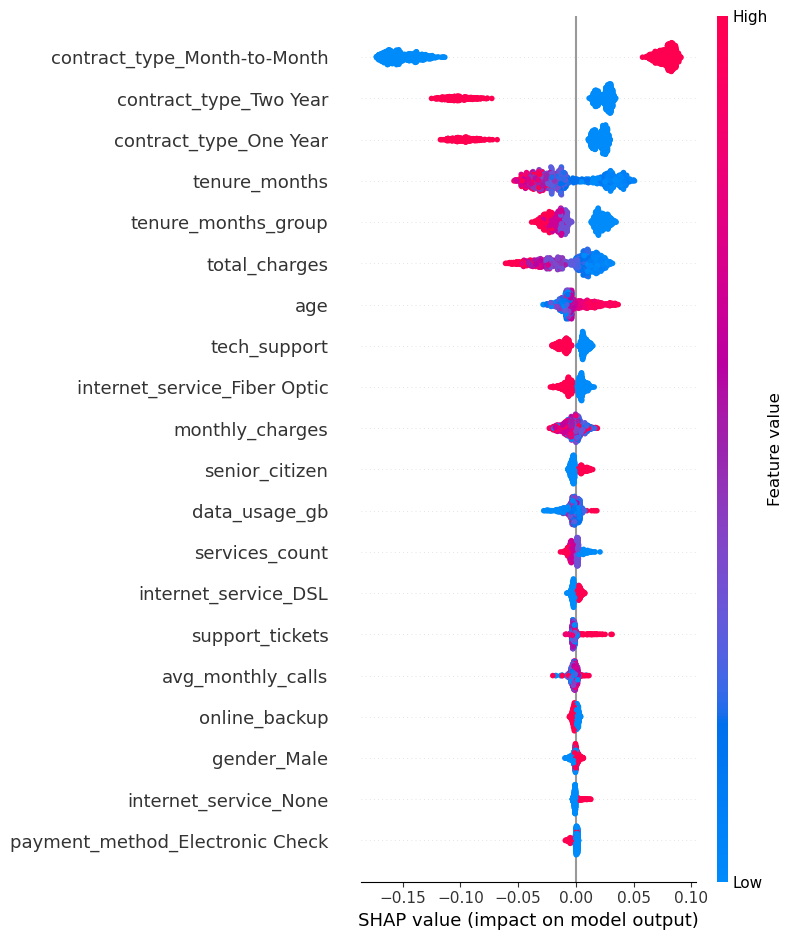

In [120]:
import shap

#import shap
import matplotlib.pyplot as plt
import numpy as np

# Extract
preprocess = rf_model_best.named_steps['preprocessor']
rf_model = rf_model_best.named_steps['model']

# Transform
X_test_transformed = preprocess.transform(X_test)
X_test_transformed = np.array(X_test_transformed, dtype=float)

# Feature names
feature_names = preprocess.get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]

# SHAP
explainer = shap.TreeExplainer(rf_model)


shap_values = explainer(X_test_transformed)

# Plot
shap.summary_plot(
    shap_values[:, :, 1],   # class 1 (churn)
    X_test_transformed,
    feature_names=feature_names
)

### Insights
**Top Drivers of Churn**
1. Contract Type (Dominant Driver): contract_type_Month-to-Month (highest).Month-to-month customers churn the most.Longer contracts reduce churn significantly. As there is no commitment from customer it is easy to leave. Long-term contracts locks the customer, making it difficult to leave.
2. Tenure Month: New Customer churns more while loyal customer churn less.
3. Total Charge: Low spending Customer are more likely to churn compare to high value customer